# ML Modeling #

In this section, we will be applying a supervised machine learning techniques to analyze demo availability in video games. Since the goal of the ml model is to predict if a game has a demo, a claassification model will be used. 

### Goal: ###
* The model aims to predict whether games with demos can be distinguished from games without demos using metacritic scores and global sales data.


## Import the Necessary Libraries ##

In [ ]:
#AI tools were used for guidance in structuring the analysis and debugging the code
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")


## Read Datasets ##

In [3]:
# load the datasets
base_games = pd.read_csv("base_games.csv")
demos = pd.read_csv("demos.csv")
sales = pd.read_csv("vgsales.csv")



## Merging the Datasets ##

In this step, we prepare **Steam base game dataset** and **global sales dataset** for analysis. 

Then, the **Steam base game dataset** is merged with the **global sales dataset** using cleaned game titles as common key.


In [ ]:
# prepare Steam Base Games Data
base_games['metacritic']=pd.to_numeric(base_games['metacritic'], errors='coerce')

# create demo label using appid matching
base_games['has_demo']=base_games['steam_appid'].isin(demos['full_game_appid'])

# clean title for merging

def clean_title(t):
    if pd.isna(t):
        return np.nan
    t = str(t).lower()
    t = ''.join(ch for ch in t if ch.isalnum() or ch.isspace())
    t = ' '.join(t.split())
    return t
base_games['base_name']=base_games['name'].apply(clean_title)

print("Prepared base_games shape:", base_games.shape)
print("Demo label counts:\n", base_games['has_demo'].value_counts())

# prepare Sales Data
sales['Global_Sales'] = pd.to_numeric(sales['Global_Sales'], errors='coerce')
sales['base_name'] = sales['Name'].apply(clean_title)

print("Prepared sales shape:", sales.shape)
print("Sales NaN count:", sales['Global_Sales'].isna().sum())


Prepared base_games shape: (116761, 14)
Demo label counts:
 has_demo
False    108127
True       8634
Name: count, dtype: int64
Prepared sales shape: (16598, 12)
Sales NaN count: 0


In [19]:
# Merge steam and sales on base_name

merged_df = pd.merge(
    base_games,
    sales[['base_name', 'Global_Sales']],
    on='base_name',
    how='left'
)

print("Merged DataFrame Shape:", merged_df.shape)
print("Total columns:", len(merged_df.columns))
print("\nAll column names:\n")
for col in merged_df.columns:
    print("-", col)

merged_df[['name', 'metacritic', 'Global_Sales', 'has_demo']].head()


Merged DataFrame Shape: (117606, 15)
Total columns: 15

All column names:

- steam_appid
- name
- windows
- mac
- linux
- metacritic
- steam_achievements
- steam_trading_cards
- workshop_support
- genres
- achievements_total
- release_date
- has_demo
- base_name
- Global_Sales


,name,metacritic,Global_Sales,has_demo
0,Femboy Burgers,NaN,NaN,False
1,PPA Pickleball Tour 2025,NaN,NaN,False
2,Squeaky Squad,NaN,NaN,False
3,Paradox Metal,NaN,NaN,False
4,Naturpark Lillebælt VR,NaN,NaN,False


## Preparing ML Dataset ##

For supervised learning, we select the features and the target variable.

**Metacritic scores** and **global sales** are used for features.

**Demo presence** is used for target.


In [20]:
features = ['metacritic', 'Global_Sales']
target = 'has_demo'

ml_df = merged_df[features + [target]].dropna().copy()

X = ml_df[features]
y = ml_df[target]

print("ML dataset shape:", ml_df.shape)
print("Target distribution:\n", y.value_counts())

X.head() #quick check


ML dataset shape: (1079, 3)
Target distribution:
 has_demo
False    1024
True       55
Name: count, dtype: int64


,metacritic,Global_Sales
806,91.0,3.62
807,91.0,2.26
808,91.0,1.69
809,91.0,0.03
13905,90.0,0.42


## Spliting the Dataset Into Training and Testing ##

In the spliting step, we split the dataset into training and testing subsets in order to see the model performance on the unseen data.

In [21]:
# split into train and test 
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

print("Train size: ", X_train.shape)
print("Test size: ", X_test.shape)


Train size:  (755, 2)
Test size:  (324, 2)


## Training the Decision Tree ##

In this part, we train the decision tree. 
The maximum depth of the tree is limited because of overfitting.

In [22]:
dt_model = DecisionTreeClassifier(
    criterion="entropy",   
    max_depth=5,           
    random_state=42
)

dt_model.fit(X_train, y_train)
print("Model is trained.")


Model is trained.


In [23]:
y_pred = dt_model.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc:.3f}")


Accuracy: 0.944


In [ ]:
print("Classification Report:")
print(classification_report(y_test, y_pred))



Classification Report:
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       307
        True       0.00      0.00      0.00        17

    accuracy                           0.94       324
   macro avg       0.47      0.50      0.49       324
weighted avg       0.90      0.94      0.92       324



Confusion Matrix:
[[306   1]
 [ 17   0]]


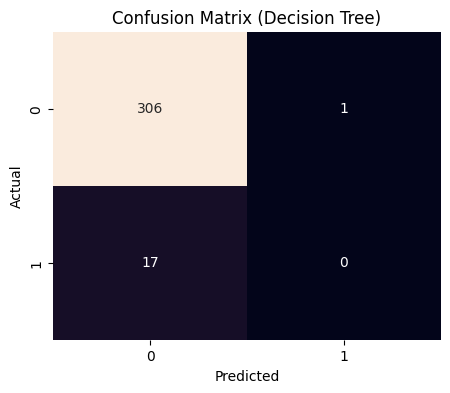

In [25]:
con_m = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(con_m)

plt.figure(figsize=(5, 4))
sns.heatmap(con_m, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (Decision Tree)")
plt.show()


## Feature Importance for Decision Tree ##

We get the feature values to analyze the contribution of each feature in predicting demo presence.


Decision Tree Feature Importances:
        feature  importance
0    metacritic    0.563883
1  Global_Sales    0.436117


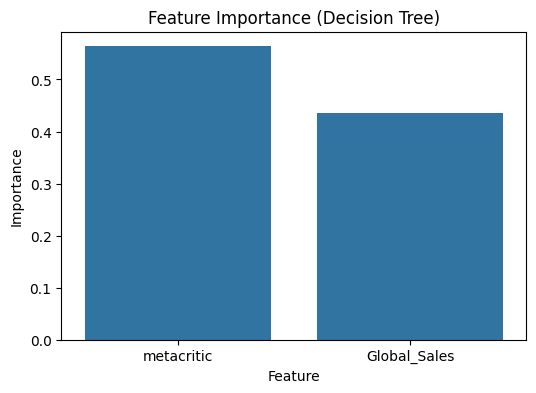

In [26]:
# Feature importance (Decision Tree)
importances = dt_model.feature_importances_

feat_imp = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

print("Decision Tree Feature Importances:")
print(feat_imp)

plt.figure(figsize=(6, 4))
sns.barplot(data=feat_imp, x="feature", y="importance")
plt.title("Feature Importance (Decision Tree)")
plt.xlabel("Feature")
plt.ylabel("Importance")
plt.show()


## Implementing KNN Model ##

We train K-nearest neighbors classifier as a comparison model.

Since it uses a distance based structure, feature scaling is used.

KNN Accuracy (k=5): 0.951

KNN Classification Report:
              precision    recall  f1-score   support

       False       0.95      1.00      0.97       307
        True       1.00      0.06      0.11        17

    accuracy                           0.95       324
   macro avg       0.98      0.53      0.54       324
weighted avg       0.95      0.95      0.93       324

KNN Confusion Matrix:
[[307   0]
 [ 16   1]]


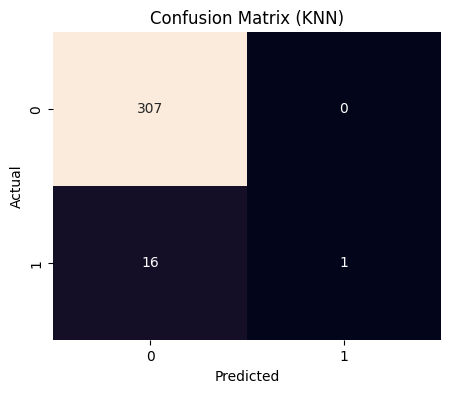

In [27]:
# KNN requires feature scaling because it uses distances
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

knn_model = KNeighborsClassifier(n_neighbors=5)
knn_model.fit(X_train_scaled, y_train)

y_pred_knn = knn_model.predict(X_test_scaled)

acc_knn = accuracy_score(y_test, y_pred_knn)
print(f"KNN Accuracy (k=5): {acc_knn:.3f}")

print("\nKNN Classification Report:")
print(classification_report(y_test, y_pred_knn))

con_m_knn = confusion_matrix(y_test, y_pred_knn)
print("KNN Confusion Matrix:")
print(con_m_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(con_m_knn, annot=True, fmt="d", cbar=False)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix (KNN)")
plt.show()


## Comparing Decision Tree and KNN ##

Lastly, both models are compared based on classification accuracy.

In [28]:
results = pd.DataFrame(
{
        "Model": ["Decision Tree (entropy)", "KNN (k=5)"],
        "Accuracy": [acc, acc_knn]
    }
)

results


,Model,Accuracy
0,Decision Tree (entropy),0.944444
1,KNN (k=5),0.950617


## Limitations ##

Eventhough the accuracy values are high, model performance should be interpreted cautiously.

Since the dataset is imbalanced which fewer games offering demos, the models ability to identify demo games are limited.